<a href="https://colab.research.google.com/github/prasannamula05/ECG-Arrhythmia-Detection-Using-HRV-and-ML/blob/main/1D-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb numpy scipy scikit-learn matplotlib seaborn tensorflow PyWavelets imbalanced-learn -q
print('✅ Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 123.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
✅ Done


In [ ]:
USE_CNN    = False      # set False to skip CNN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wfdb
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.interpolate import interp1d
import pywt

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── CONFIG ──
WIN_PRE    = 100
WIN_POST   = 200
WIN_LEN    = WIN_PRE + WIN_POST
N_FOLDS    = 5
USE_CNN    = True       # set False to skip CNN
CNN_EPOCHS = 20         # set 3 for quick test

RECORDS = [
    '105','106','107','108','109','111','112','113','114','115',
    '116','117','118','119','121','122','123','124','200','201',
    '202','203','205','207','208','209','210','212','213','214',
    '215','217','219','220','221','222','223','228','230','231',
    '232','233','234'
]

LABEL_MAP = {
    '105':1,'106':1,'107':1,'108':1,'109':1,'111':1,'112':0,'113':0,
    '114':1,'115':0,'116':1,'117':0,'118':1,'119':1,'121':1,'122':0,
    '123':0,'124':1,'200':1,'201':1,'202':1,'203':1,'205':1,'207':1,
    '208':1,'209':1,'210':1,'212':0,'213':1,'214':1,'215':1,'217':1,
    '219':1,'220':0,'221':1,'222':0,'223':1,'228':1,'230':1,'231':1,
    '232':1,'233':1,'234':1
}

print('✅ Config ready')

TensorFlow: 2.19.0
GPU: True
✅ Config ready


In [ ]:
CNN_EPOCHS = 3

In [ ]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

def detect_rpeaks(ecg, fs):
    min_dist  = int(0.5 * fs)
    threshold = 0.3 * np.max(ecg)
    peaks, _  = find_peaks(ecg, distance=min_dist, height=threshold)
    return peaks

def extract_beats(ecg, r_peaks, win_pre, win_post):
    beats = []
    for r in r_peaks:
        if r >= win_pre and r + win_post <= len(ecg):
            beat = ecg[r - win_pre : r + win_post]
            beat = (beat - np.min(beat)) / (np.ptp(beat) + 1e-8)
            beats.append(beat)
    return np.array(beats)

def compute_rr(r_peaks, fs):
    rr = np.diff(r_peaks) / fs
    return rr[(rr > 0.3) & (rr < 2.0)]

print('✅ Signal functions ready')

✅ Signal functions ready


In [ ]:
def hrv_time(rr):
    if len(rr) < 5:
        return np.zeros(5)
    return np.array([
        np.mean(rr),
        np.std(rr),
        np.sqrt(np.mean(np.diff(rr)**2)),
        np.sum(np.abs(np.diff(rr)) > 0.05) / len(rr) * 100,
        np.std(rr) / (np.mean(rr) + 1e-8)
    ])

def hrv_freq(rr, fs_rr=4.0):
    if len(rr) < 10:
        return np.zeros(3)
    t_rr  = np.cumsum(np.concatenate([[0], rr]))
    t_uni = np.arange(t_rr[0], t_rr[-1], 1/fs_rr)
    if len(t_uni) < 8:
        return np.zeros(3)
    interp  = interp1d(t_rr, np.concatenate([[rr[0]], rr]),
                       kind='cubic', fill_value='extrapolate')
    rr_uni  = interp(t_uni)
    f, pxx  = welch(rr_uni - np.mean(rr_uni), fs=fs_rr,
                    nperseg=min(256, len(rr_uni)))
    lf = np.trapz(pxx[(f>=0.04)&(f<=0.15)], f[(f>=0.04)&(f<=0.15)])
    hf = np.trapz(pxx[(f>=0.15)&(f<=0.40)], f[(f>=0.15)&(f<=0.40)])
    return np.array([lf, hf, lf/(hf+1e-8)])

def dwt_features(beat, wavelet='db4', level=4):
    coeffs = pywt.wavedec(beat, wavelet, level=level)
    feats  = []
    for c in coeffs:
        feats.extend([
            np.sum(c**2),
            np.mean(np.abs(c)),
            np.std(c),
            np.max(np.abs(c))
        ])
    return np.array(feats)   # 20 features

print('✅ Feature functions ready')

✅ Feature functions ready


In [ ]:
all_beats    = []
all_features = []
all_labels   = []

for rec_id in RECORDS:
    try:
        record  = wfdb.rdrecord(rec_id, pn_dir='mitdb')
        ecg_raw = record.p_signal[:, 0]
        fs      = record.fs
    except Exception as e:
        print(f'  [SKIP] {rec_id}: {e}')
        continue

    label = LABEL_MAP[rec_id]

    ecg = bandpass_filter(ecg_raw, fs)
    ecg = (ecg - np.min(ecg)) / (np.ptp(ecg) + 1e-8) * 2 - 1

    r_peaks = detect_rpeaks(ecg, fs)
    rr      = compute_rr(r_peaks, fs)
    if len(rr) < 10:
        continue

    rr_t = hrv_time(rr)
    rr_f = hrv_freq(rr)

    beats = extract_beats(ecg, r_peaks, WIN_PRE, WIN_POST)
    if len(beats) == 0:
        continue

    for beat in beats:
        all_beats.append(beat)
        all_features.append(np.concatenate([rr_t, rr_f, dwt_features(beat)]))
        all_labels.append(label)

    print(f'  ✅ {rec_id}: {len(beats)} beats | label={label}')

X_beats    = np.array(all_beats,    dtype=np.float32)
X_features = np.array(all_features, dtype=np.float32)
y          = np.array(all_labels,   dtype=np.int32)

print(f'\nTotal beats : {len(y)}')
print(f'Arrhythmia  : {np.sum(y==1)}')
print(f'Normal      : {np.sum(y==0)}')

  ✅ 105: 2423 beats | label=1
  ✅ 106: 1431 beats | label=1
  ✅ 107: 2092 beats | label=1
  ✅ 108: 207 beats | label=1
  ✅ 109: 2465 beats | label=1
  ✅ 111: 2022 beats | label=1
  ✅ 112: 2538 beats | label=0
  ✅ 113: 1790 beats | label=0
  ✅ 114: 1719 beats | label=1
  ✅ 115: 1950 beats | label=0
  ✅ 116: 2271 beats | label=1
  ✅ 117: 1534 beats | label=0
  ✅ 118: 2268 beats | label=1
  ✅ 119: 1986 beats | label=1
  ✅ 121: 1856 beats | label=1
  ✅ 122: 2474 beats | label=0
  ✅ 123: 1517 beats | label=0
  ✅ 124: 1600 beats | label=1
  ✅ 200: 2477 beats | label=1
  ✅ 201: 1727 beats | label=1
  ✅ 202: 1838 beats | label=1
  ✅ 203: 2177 beats | label=1
  ✅ 205: 2632 beats | label=1
  ✅ 207: 391 beats | label=1
  ✅ 208: 2557 beats | label=1
  ✅ 209: 2764 beats | label=1
  ✅ 210: 2434 beats | label=1
  ✅ 212: 2728 beats | label=0
  ✅ 213: 3184 beats | label=1
  ✅ 214: 2180 beats | label=1
  ✅ 217: 1390 beats | label=1
  ✅ 219: 2138 beats | label=1
  ✅ 220: 2020 beats | label=0
  ✅ 221: 195

In [ ]:
smote = SMOTE(k_neighbors=5, random_state=42)

X_feat_bal,  y_bal = smote.fit_resample(X_features, y)
X_beats_bal, _     = smote.fit_resample(X_beats, y)

print(f'After SMOTE:')
print(f'  Features shape : {X_feat_bal.shape}')
print(f'  Beats shape    : {X_beats_bal.shape}')
print(f'  Arrhythmia: {np.sum(y_bal==1)} | Normal: {np.sum(y_bal==0)}')

After SMOTE:
  Features shape : (131682, 28)
  Beats shape    : (131682, 300)
  Arrhythmia: 65841 | Normal: 65841


In [ ]:
def build_cnn():
    inp = layers.Input(shape=(WIN_LEN, 1))

    x = layers.Conv1D(32, 7, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.30)(x)

    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(128, activation='relu',
                       kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.50)(x)
    out = layers.Dense(2, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

build_cnn().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 300, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 75, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,930 (206.76 KB)

 Trainable params: 52,482 (205.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

results = {name: {'acc':[],'prec':[],'rec':[],'f1':[],'auc':[],
                  'cm':np.zeros((2,2)),'fpr':[],'tpr':[]}
           for name in (['SVM','KNN','Decision Tree'] +
                        (['1D CNN'] if USE_CNN else []))}

def log_metrics(results, name, y_true, y_pred, y_prob):
    results[name]['acc'].append(accuracy_score(y_true, y_pred))
    results[name]['prec'].append(precision_score(y_true, y_pred, zero_division=0))
    results[name]['rec'].append(recall_score(y_true, y_pred, zero_division=0))
    results[name]['f1'].append(f1_score(y_true, y_pred, zero_division=0))
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    results[name]['auc'].append(auc(fpr, tpr))
    results[name]['cm']  += confusion_matrix(y_true, y_pred)
    results[name]['fpr'].append(fpr)
    results[name]['tpr'].append(tpr)

for fold, (tr, te) in enumerate(skf.split(X_feat_bal, y_bal)):
    print(f'\n── Fold {fold+1}/{N_FOLDS} ──')
    Xtr, Xte = X_feat_bal[tr], X_feat_bal[te]
    ytr, yte = y_bal[tr],      y_bal[te]

    sc  = StandardScaler()
    Xts = sc.fit_transform(Xtr)
    Xes = sc.transform(Xte)

    # SVM
    svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
    svm.fit(Xts, ytr)
    log_metrics(results, 'SVM', yte, svm.predict(Xes), svm.predict_proba(Xes)[:,1])
    print(f'  SVM           F1={results["SVM"]["f1"][-1]:.4f}')

    # KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(Xts, ytr)
    log_metrics(results, 'KNN', yte, knn.predict(Xes), knn.predict_proba(Xes)[:,1])
    print(f'  KNN           F1={results["KNN"]["f1"][-1]:.4f}')

    # Decision Tree
    tree = DecisionTreeClassifier(max_depth=10, random_state=42)
    tree.fit(Xts, ytr)
    log_metrics(results, 'Decision Tree', yte, tree.predict(Xes), tree.predict_proba(Xes)[:,1])
    print(f'  Decision Tree F1={results["Decision Tree"]["f1"][-1]:.4f}')

    # 1D CNN
    if USE_CNN:
        Xtr_c = X_beats_bal[tr][..., np.newaxis]
        Xte_c = X_beats_bal[te][..., np.newaxis]
        cnn   = build_cnn()
        cnn.fit(Xtr_c, ytr,
                validation_data=(Xte_c, yte),
                epochs=CNN_EPOCHS, batch_size=64,
                callbacks=[
                    callbacks.EarlyStopping(patience=5, restore_best_weights=True),
                    callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
                ], verbose=0)
        prob = cnn.predict(Xte_c, verbose=0)[:,1]
        log_metrics(results, '1D CNN', yte, (prob>=0.5).astype(int), prob)
        print(f'  1D CNN        F1={results["1D CNN"]["f1"][-1]:.4f}')

print('\n✅ Training complete')


── Fold 1/5 ──
  SVM           F1=0.9998
  KNN           F1=0.9996
  Decision Tree F1=0.9989
  1D CNN        F1=0.9953

── Fold 2/5 ──
  SVM           F1=0.9998
  KNN           F1=0.9995
  Decision Tree F1=0.9990
  1D CNN        F1=0.9817

── Fold 3/5 ──
  SVM           F1=0.9997
  KNN           F1=0.9995
  Decision Tree F1=0.9990
  1D CNN        F1=0.9820

── Fold 4/5 ──
  SVM           F1=0.9998
  KNN           F1=0.9997
  Decision Tree F1=0.9988
  1D CNN        F1=0.9486

── Fold 5/5 ──
  SVM           F1=0.9999
  KNN           F1=0.9997
  Decision Tree F1=0.9987
  1D CNN        F1=0.9667

✅ Training complete


In [ ]:
print('='*72)
print(f'{"Model":<16}{"Accuracy":>10}{"Precision":>11}{"Recall":>9}{"F1":>9}{"AUC":>9}')
print('-'*72)
for name, m in results.items():
    print(f'{name:<16}'
          f'{np.mean(m["acc"]):>10.4f}'
          f'{np.mean(m["prec"]):>11.4f}'
          f'{np.mean(m["rec"]):>9.4f}'
          f'{np.mean(m["f1"]):>9.4f}'
          f'{np.mean(m["auc"]):>9.4f}')
print('-'*72)
print(f'{"(±Std)":<16}')
for name, m in results.items():
    print(f'{name:<16}'
          f'±{np.std(m["acc"]):>9.4f}'
          f'±{np.std(m["prec"]):>10.4f}'
          f'±{np.std(m["rec"]):>8.4f}'
          f'±{np.std(m["f1"]):>8.4f}'
          f'±{np.std(m["auc"]):>8.4f}')
print('='*72)


Model             Accuracy  Precision   Recall       F1      AUC
------------------------------------------------------------------------
SVM                 0.9998     0.9999   0.9997   0.9998   1.0000
KNN                 0.9996     0.9997   0.9995   0.9996   0.9999
Decision Tree       0.9989     0.9999   0.9979   0.9989   0.9991
1D CNN              0.9745     0.9716   0.9793   0.9749   0.9982
------------------------------------------------------------------------
(±Std)          
SVM             ±   0.0001±    0.0001±  0.0001±  0.0001±  0.0000
KNN             ±   0.0001±    0.0001±  0.0001±  0.0001±  0.0000
Decision Tree   ±   0.0001±    0.0001±  0.0002±  0.0001±  0.0001
1D CNN          ±   0.0168±    0.0340±  0.0194±  0.0160±  0.0011


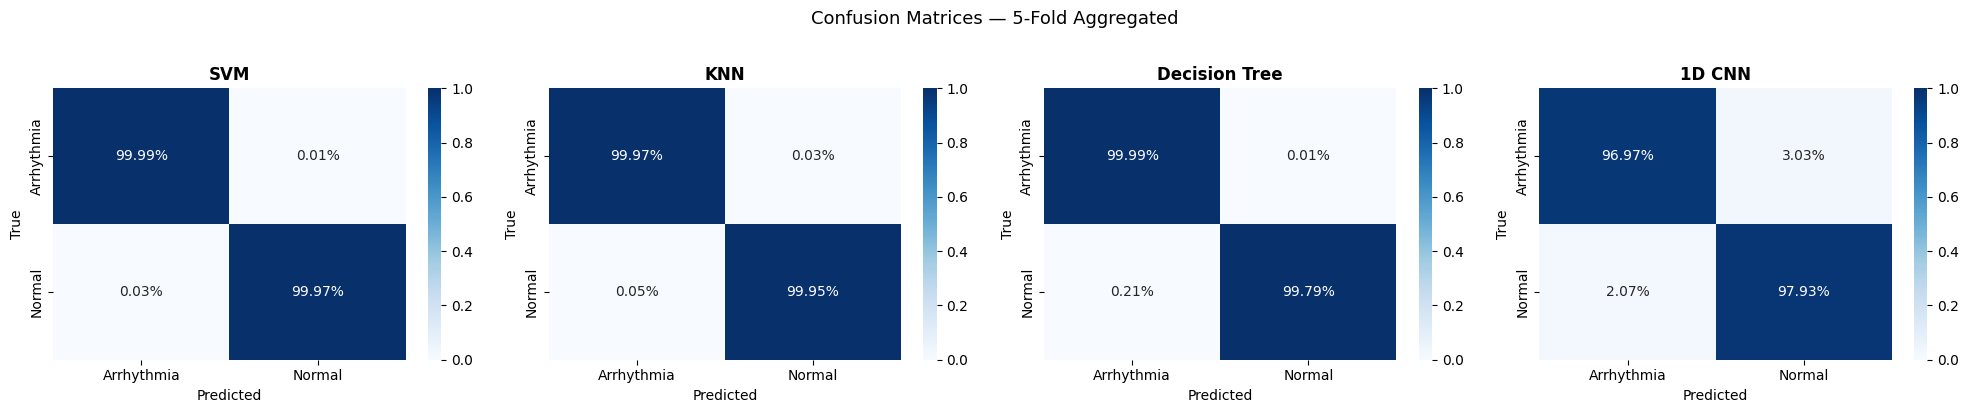

In [ ]:
n  = len(results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]

for ax, (name, m) in zip(axes, results.items()):
    cm_n = m['cm'] / m['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=['Arrhythmia','Normal'],
                yticklabels=['Arrhythmia','Normal'], vmin=0, vmax=1)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — 5-Fold Aggregated', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

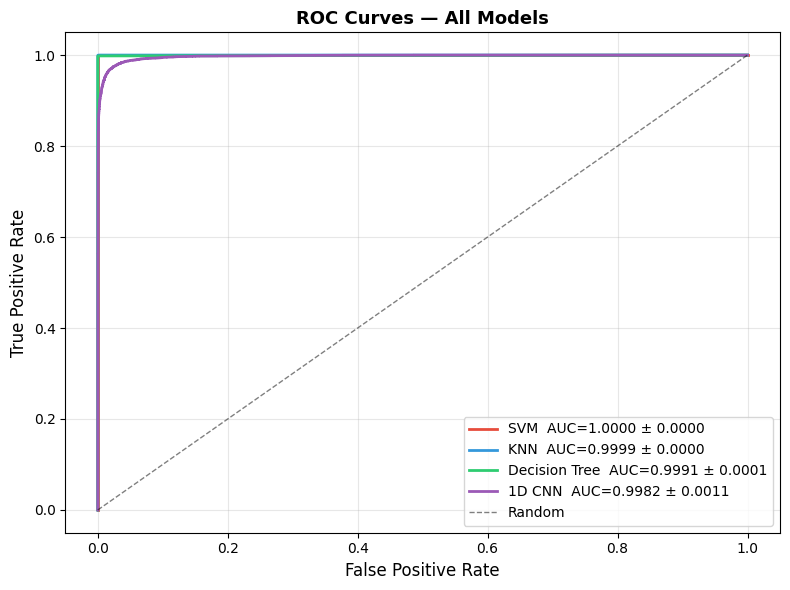

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

for (name, m), color in zip(results.items(), colors):
    ax.plot(m['fpr'][-1], m['tpr'][-1], color=color, lw=2,
            label=f'{name}  AUC={np.mean(m["auc"]):.4f} ± {np.std(m["auc"]):.4f}')

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

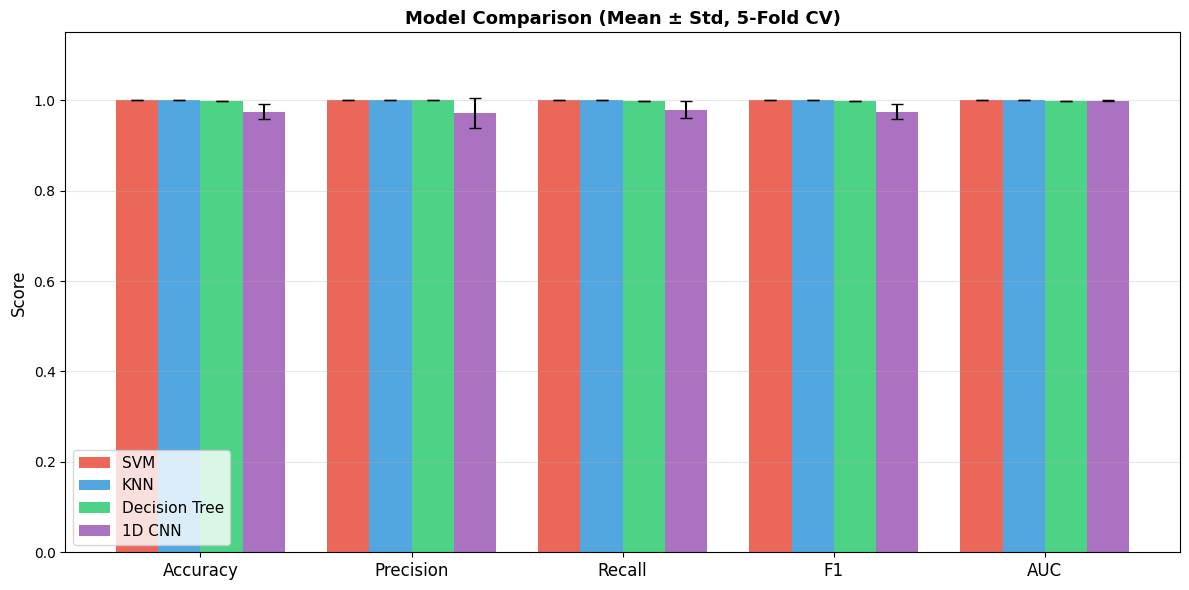

In [ ]:
metrics_keys   = ['acc','prec','rec','f1','auc']
metrics_labels = ['Accuracy','Precision','Recall','F1','AUC']
model_names    = list(results.keys())
colors         = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

data = np.array([[np.mean(results[n][k]) for k in metrics_keys] for n in model_names])
errs = np.array([[np.std(results[n][k])  for k in metrics_keys] for n in model_names])

x   = np.arange(len(metrics_labels))
w   = 0.8 / len(model_names)
fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    offset = (i - len(model_names)/2 + 0.5) * w
    ax.bar(x + offset, data[i], w, yerr=errs[i], label=name,
           color=color, alpha=0.85, capsize=4)

ax.set_xticks(x); ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim([0, 1.15]); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison (Mean ± Std, 5-Fold CV)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()